# Data Analysis
## Load Data
### Imports

In [3]:
import os 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import ipywidgets as widgets
from IPython.display import display, clear_output

from scipy.stats import linregress

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression

### Load Data

In [4]:
base_dir = os.getcwd()
data_dir = os.path.join(base_dir, 'data')

ausgrid_complete_filepath = os.path.join(data_dir, 'ausgrid_complete.csv')
ausgrid_ppv_filepath = os.path.join(data_dir, 'ausgrid_ppv.csv')

# ausgrid_complete = pd.read_csv(ausgrid_complete_filepath)
ausgrid_ppv = pd.read_csv(ausgrid_ppv_filepath)

# Inspect data
print(f"Name: Ausgrid PPV Data")
print(f"Shape: {ausgrid_ppv.shape}")
print(f"Columns:", ausgrid_ppv.columns.tolist())
print(f"Missing values: {ausgrid_ppv.isna().sum().sum()}")
ausgrid_ppv.head()

Name: Ausgrid PPV Data
Shape: (15780012, 20)
Columns: ['Customer', 'Generator Capacity', 'Postcode', 'datetime', 'PPV', 'temperature_2m', 'wind_speed_10m', 'shortwave_radiation', 'cloud_cover', 'direct_normal_irradiance', 'diffuse_radiation', 'sunshine_duration', 'solar_zenith', 'solar_azimuth', 'panel_tilt', 'panel_azimuth', 'angle_of_incidence', 'POA', 'eta_irradiance', 'POA_adjusted']
Missing values: 21600


,Customer,Generator Capacity,Postcode,datetime,PPV,temperature_2m,wind_speed_10m,shortwave_radiation,cloud_cover,direct_normal_irradiance,diffuse_radiation,sunshine_duration,solar_zenith,solar_azimuth,panel_tilt,panel_azimuth,angle_of_incidence,POA,eta_irradiance,POA_adjusted
0,1,3.78,2076,2010-07-01 00:00:00,0.0,4.00,9.10,0.0,0.0,0.0,0.0,0.0,122.947251,0.311255,52.803409,195.253396,167.071071,0.0,0.0,0.0
1,1,3.78,2076,2010-07-01 00:30:00,0.0,3.80,8.70,0.0,0.5,0.0,0.0,0.0,122.470484,8.487010,52.803409,195.253396,172.711115,0.0,0.0,0.0
2,1,3.78,2076,2010-07-01 01:00:00,0.0,3.60,8.30,0.0,1.0,0.0,0.0,0.0,121.126524,16.445188,52.803409,195.253396,173.850525,0.0,0.0,0.0
3,1,3.78,2076,2010-07-01 01:30:00,0.0,3.45,8.35,0.0,5.0,0.0,0.0,0.0,118.973260,24.013763,52.803409,195.253396,168.988341,0.0,0.0,0.0
4,1,3.78,2076,2010-07-01 02:00:00,0.0,3.30,8.40,0.0,9.0,0.0,0.0,0.0,116.093448,31.080145,52.803409,195.253396,162.585127,0.0,0.0,0.0


## Interactive PV Profiles
### Daily PV Profile
#### Prepare Data

In [5]:
# Prepare data
df = ausgrid_ppv.copy()
df["datetime"] = pd.to_datetime(df["datetime"])

df["date"] = df["datetime"].dt.date
df["time"] = (
    df["datetime"].dt.hour
    + df["datetime"].dt.minute / 60)

# Get available customers
customers = sorted(df["Customer"].dropna().unique())

# Get available numeric variables
variables = [
    col for col in df.columns
    if col not in ["datetime", "date", "time", "Customer"]
    and pd.api.types.is_numeric_dtype(df[col])]

#### Create interactive controls

In [6]:
# Customer dropdown
customer_dropdown = widgets.Dropdown(
    options=customers,
    description="Customer:",
    layout=widgets.Layout(width="400px"))

# Date dropdown
date_dropdown = widgets.Dropdown(
    description="Date:",
    layout=widgets.Layout(width="400px"))

# Variable dropdown
variable_dropdown = widgets.Dropdown(
    options=variables,
    value="PPV" if "PPV" in variables else variables[0],
    description="Variable:",
    layout=widgets.Layout(width="400px"))

# Normalize toggle
normalize_toggle = widgets.ToggleButton(
    value=False,
    description="Normalize: OFF",
    button_style="",
    layout=widgets.Layout(width="150px"))

add_button = widgets.Button(
    description="Add profile",
    button_style="primary",
    layout=widgets.Layout(width="150px"))

clear_button = widgets.Button(
    description="Clear profiles",
    layout=widgets.Layout(width="150px"))

output = widgets.Output()

#### Define functions for updating the dashboard

In [7]:
# Store profiles that have been added
# (customer, date, variable, normalized)
profiles = []

# Update available dates when the customer changes
def update_dates(change):
    customer = change["new"]

    customer_df = df[df["Customer"] == customer]
    dates = sorted(customer_df["date"].unique())

    date_dropdown.options = dates

    if dates:
        date_dropdown.value = dates[0]

# Update toggle label
def update_normalize_button(change):
    if change["new"]:
        normalize_toggle.description = "Normalize: ON"
        normalize_toggle.button_style = "success"
    else:
        normalize_toggle.description = "Normalize: OFF"
        normalize_toggle.button_style = ""

# Draw all currently selected profiles
def update_plot(change=None):

    with output:
        clear_output(wait=True)

        plt.figure(figsize=(10, 5))

        # Plot every profile currently stored
        for customer, date, variable, normalized in profiles:

            day_df = df[
                (df["Customer"] == customer) &
                (df["date"] == date)
            ].sort_values("datetime")

            if day_df.empty:
                continue

            y = day_df[variable].copy()

            # Normalize this individual profile to 0–1
            if normalized:
                y_min = y.min()
                y_max = y.max()

                if y_max != y_min:
                    y = (y - y_min) / (y_max - y_min)
                else:
                    # Constant profile
                    y = 0

            normalization_label = " (normalized)" if normalized else ""

            plt.plot(
                day_df["time"],
                y,
                label=f"Customer {customer} — {date} — {variable}{normalization_label}"
            )

        plt.xlabel("Time of day")

        # No Y-axis label because multiple variables may be plotted

        if profiles:
            plt.title("Selected profiles")
            plt.legend()
        else:
            plt.title("No profiles selected")

        plt.grid(True)
        plt.tight_layout()
        plt.show()

def add_profile(change=None):

    customer = customer_dropdown.value
    date = date_dropdown.value
    variable = variable_dropdown.value
    normalized = normalize_toggle.value

    if customer is None or date is None or variable is None:
        return

    profile = (customer, date, variable, normalized)

    # Prevent duplicate profiles
    if profile not in profiles:

        add_button.description = "Adding..."
        add_button.disabled = True

        profiles.append(profile)

        update_plot()

        add_button.description = "Add profile"
        add_button.disabled = False

# Remove all profiles from the plot
def clear_profiles(change=None):
    profiles.clear()
    update_plot()

#### Connect and initialize the dashboard

In [8]:
# Connect widgets
customer_dropdown.observe(update_dates, names="value")
date_dropdown.observe(update_plot, names="value")
variable_dropdown.observe(update_plot, names="value")
normalize_toggle.observe(update_normalize_button, names="value")

add_button.on_click(add_profile)
clear_button.on_click(clear_profiles)

# Initialize the date dropdown
update_dates({"new": customer_dropdown.value})

# Display dashboard
display(
    widgets.VBox([
        customer_dropdown,
        date_dropdown,
        widgets.HBox([
            variable_dropdown,
            normalize_toggle
        ]),
        widgets.HBox([
            add_button,
            clear_button
        ])
    ]),
    output
)

# Initial empty plot
update_plot()

Output(outputs=({'output_type': 'display_data', 'data': {'text/plain': '<Figure size 1000x500 with 1 Axes>', '…

### Yearly profile
#### Prepare yearly data

In [9]:
# Add year information for yearly profiles
df["year"] = df["datetime"].dt.year
df["day_of_year"] = df["datetime"].dt.dayofyear

#### Create yearly customer and year selectors

In [10]:
# Create yearly profile controls
year_customer_dropdown = widgets.Dropdown(
    options=customers,
    description="Customer:",
    layout=widgets.Layout(width="400px")
)

year_dropdown = widgets.Dropdown(
    description="Year:",
    layout=widgets.Layout(width="400px")
)

year_output = widgets.Output()

#### Define the yearly dashboard functions

In [11]:
# Update available years when customer changes
def update_years(change):
    customer = change["new"]

    customer_df = df[df["Customer"] == customer]
    years = sorted(customer_df["year"].unique())

    year_dropdown.options = years

    if years:
        year_dropdown.value = years[0]


# Draw all currently selected yearly profiles
def update_year_plot():
    with year_output:
        clear_output(wait=True)

        plt.figure(figsize=(10, 5))

        for customer, year in year_profiles:

            year_df = df[
                (df["Customer"] == customer) &
                (df["year"] == year)
            ]

            # Calculate mean PPV for each day
            daily_ppv = (
                year_df
                .groupby("day_of_year")["PPV"]
                .mean()
            )

            plt.plot(
                daily_ppv.index,
                daily_ppv.values,
                label=f"Customer {customer} — {year}"
            )

        plt.xlabel("Day of year")
        plt.ylabel("PPV")
        plt.title("Yearly PV Power Profiles")

        if year_profiles:
            plt.legend()

        plt.grid(True)
        plt.tight_layout()
        plt.show()


# Add the selected customer/year
def add_year_profile(change=None):
    customer = year_customer_dropdown.value
    year = year_dropdown.value

    if customer is None or year is None:
        return

    profile = (customer, year)

    if profile not in year_profiles:

        # Show loading state
        add_year_button.description = "Adding..."
        add_year_button.disabled = True

        year_profiles.append(profile)

        update_year_plot()

        # Restore button
        add_year_button.description = "Add profile"
        add_year_button.disabled = False


# Clear all yearly profiles
def clear_year_profiles(change=None):
    year_profiles.clear()
    update_year_plot()

#### Create buttons and initialize

In [12]:
# Store yearly profiles that have been added
year_profiles = []

In [13]:
# Create buttons
add_year_button = widgets.Button(
    description="Add profile",
    button_style="primary",
    layout=widgets.Layout(width="150px")
)

clear_year_button = widgets.Button(
    description="Clear profiles",
    layout=widgets.Layout(width="150px")
)


# Connect widgets
year_customer_dropdown.observe(update_years, names="value")
add_year_button.on_click(add_year_profile)
clear_year_button.on_click(clear_year_profiles)


# Initialize year dropdown
update_years({"new": year_customer_dropdown.value})


# Display yearly dashboard
display(
    widgets.VBox([
        year_customer_dropdown,
        year_dropdown,
        widgets.HBox([
            add_year_button,
            clear_year_button
        ])
    ]),
    year_output
)


# Initial empty plot
update_year_plot()

Output()

## Interactive Scatterpot
### Prepare data

In [14]:
# Prepare data for scatterplot exploration
scatter_df = ausgrid_ppv.copy()
scatter_df["datetime"] = pd.to_datetime(scatter_df["datetime"])

# Candidate independent variables
independent_variables = [
    col for col in scatter_df.columns
    if col not in ["PPV", "datetime", "Customer"]
    and pd.api.types.is_numeric_dtype(scatter_df[col])]

### Create dropdowns and output area

In [15]:
# Get numeric variables that can be plotted
plot_variables = [
    col for col in scatter_df.columns
    if col not in ["datetime", "Customer"]
    and pd.api.types.is_numeric_dtype(scatter_df[col])]

# X-axis variable
x_variable_dropdown = widgets.Dropdown(
    options=plot_variables,
    description="X variable:",
    layout=widgets.Layout(width="450px"))

# Y-axis variable
y_variable_dropdown = widgets.Dropdown(
    options=plot_variables,
    value="PPV" if "PPV" in plot_variables else plot_variables[0],
    description="Y variable:",
    layout=widgets.Layout(width="450px"))

### Best-fit line type dropdown

In [16]:
# Dropdown for type of best-fit line
fit_type_dropdown = widgets.Dropdown(
    options=[
        "Linear",
        "Polynomial",
        "Exponential",
        "Logarithmic"
    ],
    value="Linear",
    description="Fit type:",
    layout=widgets.Layout(width="450px")
)

### Add button and R2 output

In [17]:
# Button for best-fit regression
fit_button = widgets.Button(
    description="Show best fit",
    button_style="primary",
    layout=widgets.Layout(width="150px")
)

# Output for regression statistics
fit_output = widgets.Output()

### Customer dropdown

In [18]:
# Customer dropdown
customer_options = ["All customers"] + sorted(
    scatter_df["Customer"].dropna().unique().tolist()
)

scatter_customer_dropdown = widgets.Dropdown(
    options=customer_options,
    value="All customers",
    description="Customer:",
    layout=widgets.Layout(width="450px"))

### Define the plotting function

In [19]:
def update_scatterplot(change=None):

    x_variable = x_variable_dropdown.value
    y_variable = y_variable_dropdown.value
    customer = scatter_customer_dropdown.value

    if x_variable is None or y_variable is None:
        return

    with scatter_output:
        clear_output(wait=True)

        # Select customer
        if customer == "All customers":
            plot_df = scatter_df
        else:
            plot_df = scatter_df[
                scatter_df["Customer"] == customer
            ]

        # Keep selected variables and remove missing values
        plot_df = plot_df[
            [x_variable, y_variable]
        ].dropna()

        plt.figure(figsize=(10, 6))

        plt.scatter(
            plot_df[x_variable],
            plot_df[y_variable],
            alpha=0.3,
            s=10
        )

        plt.xlabel(x_variable)
        plt.ylabel(y_variable)

        plt.title(
            f"{y_variable} vs. {x_variable}"
            + (
                f" — Customer {customer}"
                if customer != "All customers"
                else " — All Customers"
            )
        )

        plt.grid(True)
        plt.tight_layout()
        plt.show()

### Define the best-fit function

In [20]:
def show_best_fit(change=None):

    x_variable = x_variable_dropdown.value
    y_variable = y_variable_dropdown.value
    customer = scatter_customer_dropdown.value
    fit_type = fit_type_dropdown.value

    # Select customer
    if customer == "All customers":
        plot_df = scatter_df
    else:
        plot_df = scatter_df[
            scatter_df["Customer"] == customer
        ]

    # Keep relevant variables and remove missing values
    plot_df = plot_df[
        [x_variable, y_variable]
    ].dropna()

    x = plot_df[x_variable].values
    y = plot_df[y_variable].values

    # Remove invalid values for log-based fits
    if fit_type in ["Exponential", "Logarithmic"]:
        if fit_type == "Exponential":
            valid = (y > 0) & np.isfinite(x)
        else:
            valid = (x > 0) & np.isfinite(y)

        x = x[valid]
        y = y[valid]

    # Create x-values for fitted line
    x_fit = np.linspace(x.min(), x.max(), 200)

    # Fit selected model
    if fit_type == "Linear":

        coefficients = np.polyfit(x, y, 1)
        y_fit = np.polyval(coefficients, x)

        slope = coefficients[0]
        intercept = coefficients[1]

        ss_res = np.sum((y - y_fit) ** 2)
        ss_tot = np.sum((y - np.mean(y)) ** 2)
        r_squared = 1 - ss_res / ss_tot

        y_line = np.polyval(coefficients, x_fit)

        equation = (
            f"y = {slope:.4f}x + {intercept:.4f}"
        )

    elif fit_type == "Polynomial":

        degree = 2

        coefficients = np.polyfit(x, y, degree)
        y_fit = np.polyval(coefficients, x)

        ss_res = np.sum((y - y_fit) ** 2)
        ss_tot = np.sum((y - np.mean(y)) ** 2)
        r_squared = 1 - ss_res / ss_tot

        y_line = np.polyval(coefficients, x_fit)

        equation = (
            f"y = {coefficients[0]:.4g}x² "
            f"+ {coefficients[1]:.4g}x "
            f"+ {coefficients[2]:.4g}"
        )

    elif fit_type == "Exponential":

        # ln(y) = ln(a) + bx
        coefficients = np.polyfit(x, np.log(y), 1)

        b = coefficients[0]
        a = np.exp(coefficients[1])

        y_fit = a * np.exp(b * x)

        ss_res = np.sum((y - y_fit) ** 2)
        ss_tot = np.sum((y - np.mean(y)) ** 2)
        r_squared = 1 - ss_res / ss_tot

        y_line = a * np.exp(b * x_fit)

        equation = (
            f"y = {a:.4g}e^({b:.4g}x)"
        )

    elif fit_type == "Logarithmic":

        # y = a ln(x) + b
        coefficients = np.polyfit(np.log(x), y, 1)

        a = coefficients[0]
        b = coefficients[1]

        y_fit = a * np.log(x) + b

        ss_res = np.sum((y - y_fit) ** 2)
        ss_tot = np.sum((y - np.mean(y)) ** 2)
        r_squared = 1 - ss_res / ss_tot

        y_line = a * np.log(x_fit) + b

        equation = (
            f"y = {a:.4g}ln(x) + {b:.4g}"
        )

    # Plot
    with scatter_output:
        clear_output(wait=True)

        plt.figure(figsize=(10, 6))

        plt.scatter(
            x,
            y,
            alpha=0.3,
            s=10,
            label="Data"
        )

        plt.plot(
            x_fit,
            y_line,
            linewidth=2,
            label=f"{fit_type} best fit"
        )

        plt.xlabel(x_variable)
        plt.ylabel(y_variable)

        plt.title(
            f"{y_variable} vs. {x_variable}"
            + (
                f" — Customer {customer}"
                if customer != "All customers"
                else " — All Customers"
            )
        )

        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    # Display statistics
    with fit_output:
        clear_output(wait=True)

        print(f"Fit type: {fit_type}")
        print(f"R² = {r_squared:.4f}")
        print(f"Equation: {equation}")

### Connect controls and initialize

In [21]:
# Update plot whenever a dropdown changes
x_variable_dropdown.observe(
    update_scatterplot,
    names="value"
)

y_variable_dropdown.observe(
    update_scatterplot,
    names="value"
)


scatter_customer_dropdown.observe(
    update_scatterplot,
    names="value"
)

# Connect best-fit button
fit_button.on_click(show_best_fit)

# Output area for scatterplot
scatter_output = widgets.Output()

# Display dashboard
display(
    widgets.VBox([
        x_variable_dropdown,
        y_variable_dropdown,
        scatter_customer_dropdown,
        fit_type_dropdown,
        fit_button,
        scatter_output,
        fit_output
    ])
)

# Initial scatterplot
update_scatterplot()

## Baseline Models
### Simple Mean

In [22]:
# Mean baseline
y_true = ausgrid_ppv["PPV"].dropna()
y_pred = np.full(len(y_true), y_true.mean())

print("MAE:", mean_absolute_error(y_true, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))
print("R²:", r2_score(y_true, y_pred))

MAE: 0.1588434843417925
RMSE: 0.2444645626408063
R²: 0.0


With an an MAE of 0.159 and an RMSE of 0.244, the mean is a weak predictor. As expected, $R^2=0$ because predicting the mean explains none of the variation in PPV. 

### Historical PV

We predict each PPV observation using the PPV recorded at the same date and time exactly one year earlier. 

In [22]:
# Historical baseline: PPV from exactly one year earlier for one customer
customer_id = ausgrid_ppv["Customer"].iloc[0]

df = ausgrid_ppv[ausgrid_ppv["Customer"] == customer_id][
    ["datetime", "PPV"]
].dropna().copy()

df["datetime"] = pd.to_datetime(df["datetime"])

ppv_lookup = df.drop_duplicates("datetime").set_index("datetime")["PPV"]

prev_dates = df["datetime"] - pd.DateOffset(years=1)
df["PPV_prev_year"] = ppv_lookup.reindex(prev_dates).to_numpy()

df = df.dropna(subset=["PPV_prev_year"])

print("Customer:", customer_id)
print("MAE:", mean_absolute_error(df["PPV"], df["PPV_prev_year"]))
print("RMSE:", np.sqrt(mean_squared_error(df["PPV"], df["PPV_prev_year"])))
print("R²:", r2_score(df["PPV"], df["PPV_prev_year"]))

Customer: 1
MAE: 0.1490991422302015
RMSE: 0.32105782915679926
R²: 0.4859428536413152


For this individual customer, the previous-year PPV is a much more useful baseline than the simple mean. MAE = 0.149 and RMSE = 0.322 indicate that reasonably large prediction errors remain. $R^2=0.489$ means the previous year's PPV explains about 49% of the variation in the current year's PPV. 

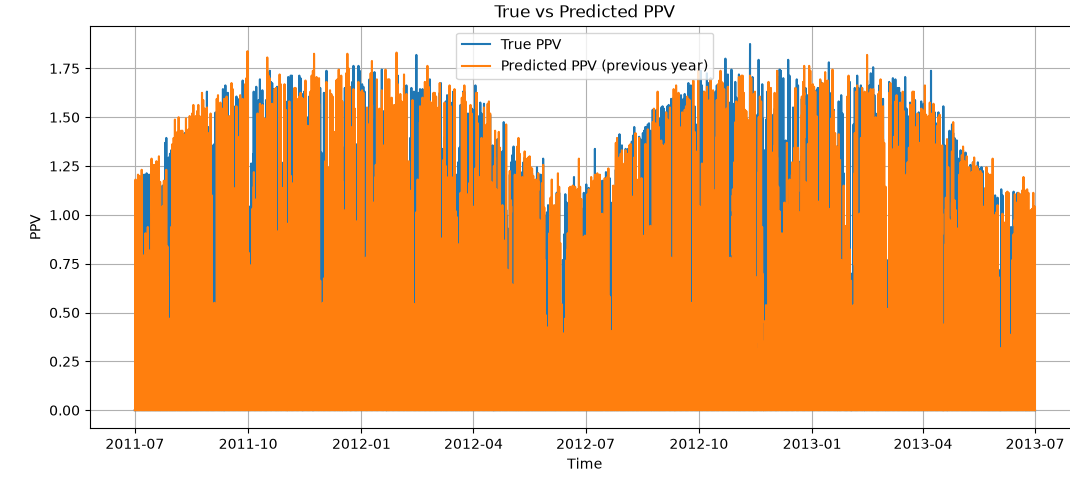

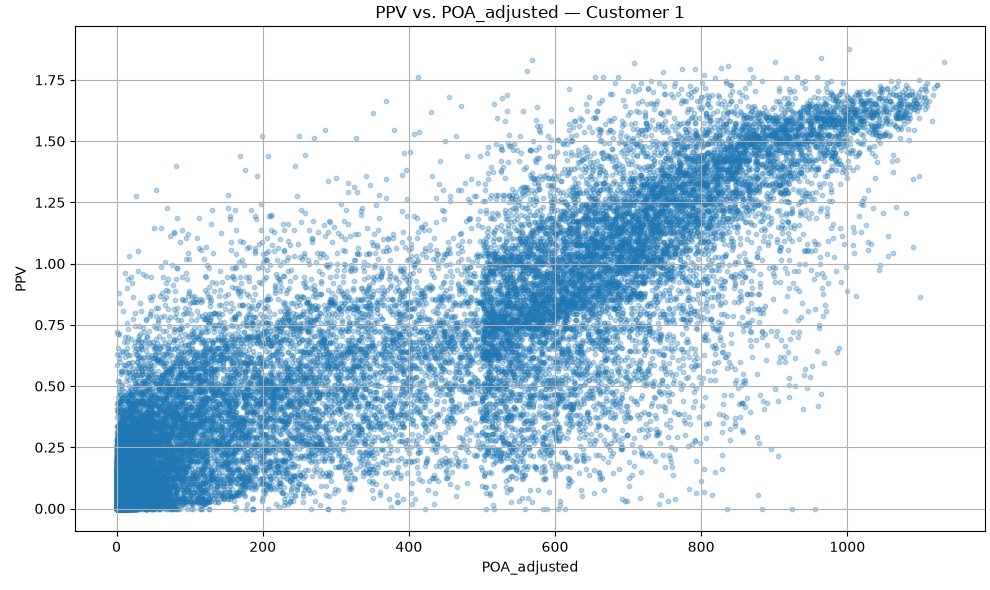

In [23]:
plt.figure(figsize=(12, 5))

plt.plot(df["datetime"], df["PPV"], label="True PPV")
plt.plot(df["datetime"], df["PPV_prev_year"], label="Predicted PPV (previous year)")

plt.xlabel("Time")
plt.ylabel("PPV")
plt.title("True vs Predicted PPV")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

The plot shows that the previous year's data captures the overall seasonal pattern and approximate magnitude, bus misses much of the day-to-day variability, particularly weather-driven fluctuations.